# <center>Lecture 4: Identification, regularization, and minimax regret</center>
### <center>Alfred Galichon (NYU)</center>
## <center>'math+econ+code' masterclass series: discrete choice</center>
#### <center>With python code examples</center>

© 2026 by Alfred Galichon. Past and present support from NSF grant DMS-1716489, ERC grant CoG-866274 are acknowledged, as well as inputs from contributors listed [here](http://www.math-econ-code.org/team).

**If you reuse material from this masterclass, please cite as:**<br>
Alfred Galichon, 'math+econ+code' masterclass series. https://www.math-econ-code.org/

This notebook is the **computational companion to chapter 3, sections 3.5–3.8** of

> A. Galichon, *Discrete Choice Models: Mathematical Methods, Econometrics, and Data Science*, Princeton University Press, 2026,

covering identification (3.5), existence and the zero-cell problem (3.6), shrinkage and regularization (3.7), and minimax regret with the small-noise limit (3.8). It runs the book's code listings `3-03`, `3-04`, `3-05` and `3-06`, and **reproduces table 3.1 of the book**. Sections 3.1–3.4 are lecture 3. Slide deck: folders `ch3/ch3.5`–`ch3/ch3.8`.

### Learning objectives

* When is $\hat\lambda$ identified? Rank of $\Phi$, and the individual-fixed-effect direction $a\otimes\mathbf 1_Y$.
* When does $\hat\lambda$ *exist*? The zero-cell problem, coercivity, and a linear program that detects failure before the optimizer diverges.
* Ridge, LASSO and elastic net; why the penalty multiplier $\gamma$ is exactly a **tolerance on moment matching**; proximal gradient and soft thresholding.
* Minimax regret estimation, its linear-programming formulation, and its dual.
* The small-noise limit: as $\sigma\to0$ the logistic estimator converges to a minimax regret estimator, and the entropy objective is replaced by a linear one on the *same* polytope.

### References

* Galichon (2026). *Discrete Choice Models*. Princeton University Press. **Chapter 3, sections 3.5–3.8**, and table 3.1, reproduced in section 4 below.
* Verbeek (1989, 1992). "The Compactification of Finite Exponential Family Models". Early treatment of the zero-cell problem.
* Santos Silva and Tenreyro (2011). "Further Simulation Evidence on the Performance of the Poisson Pseudo-Maximum Likelihood Estimator". *Economics Letters*. Non-existence in the gravity setting.
* Correia, Guimarães and Zylkin (2019). "Verifying the Existence of Maximum Likelihood Estimates for Generalized Linear Models". Detection of non-existence.
* James and Stein (1961); Tibshirani (1996), "Regression Shrinkage and Selection via the Lasso", *JRSS-B*; Hastie, Tibshirani and Friedman (2009), *The Elements of Statistical Learning*.
* Bauschke and Combettes (2017). *Convex Analysis and Monotone Operator Theory in Hilbert Spaces*. Proximal gradient.
* Savage (1951). "The Theory of Statistical Decision". *JASA*. Minimax regret.
* Bonnet, Fougère, Galichon and Poulhès (2022). "Minimax Estimation of Hedonic Models". Preprint.
* Previous lecture: `dc03_logistic-regression-and-the-glm-connection` — the estimator whose identification, existence and regularization are studied here.

## Motivation: three ways the estimator of lecture 3 can fail

Lecture 3 computed $\hat\lambda$ on the travel-mode data and treated it as a well-defined object. It need not be. Three distinct things can go wrong, and they are usually confused with one another:

1. **Identification.** The maximizer may not be unique — several $\lambda$ give the same likelihood. Section 1 shows that in the logit this happens for exactly two reasons: $\Phi$ is rank-deficient, or $\Phi$ contains an individual fixed effect in disguise.
2. **Existence.** The maximizer may not exist at all, escaping to infinity. This is the **zero-cell problem**, and section 2 gives a linear program that detects it *before* an optimizer wanders off.
3. **Overfitting.** The maximizer may exist and be unique and still be useless, because $K$ is large relative to $I$. Section 3 shrinks it, and finds that the shrinkage parameter has an exact dual meaning.

Section 4 then pushes in the opposite direction: what happens when the heterogeneity itself is scaled down to nothing. The answer connects the whole chapter to linear programming — and to lecture 1.

**The dual object.** Lecture 3 established that estimation minimizes the entropy of choice over the polytope
$$\mathcal{C} = \Big\{\pi\ge0:\ \sum_y\pi_{iy}=1\ [u_i],\quad \Phi^\top\pi = \Phi^\top\hat\pi\ [\lambda_k]\Big\}.$$
Everything in this notebook is a statement about that polytope. **Existence** fails exactly when $\mathcal{C}$ has no strictly interior point — which is what the detector LP measures. **Regularization** relaxes the moment constraints to $|\Phi^\top(\pi-\hat\pi)|_k\le\gamma$, so the penalty parameter *is* the slack allowed on each moment. And the **small-noise limit** keeps $\mathcal{C}$ exactly as it is and replaces the entropy objective by a linear one — turning the estimator into a linear program whose dual variables are still $(u_i,\lambda_k)$.

In [1]:
import numpy as np
import pandas as pd
import scipy.sparse as sp
from scipy.optimize import linprog, minimize
import matplotlib.pyplot as plt

rng = np.random.default_rng(4)          # lecture number
FAST_MODE = True

np.set_printoptions(precision=4, suppress=True)

### Machinery carried over from lecture 3

The log-likelihood, its gradient and its Hessian, and the travel-mode data loader of listing `3-09`.

In [2]:
from pathlib import Path


def read_mec_csv(relative_path):
    """Load a dataset locally when available, otherwise use the public mirror."""
    for parent in (Path.cwd(), *Path.cwd().parents):
        local = parent / 'mec_datasets' / relative_path
        if local.is_file():
            return pd.read_csv(local)
    url = ('https://raw.githubusercontent.com/math-econ-code/'
           'mec_datasets/main/' + relative_path)
    try:
        return pd.read_csv(url)
    except Exception as exc:
        raise RuntimeError(
            f'could not load {relative_path}; no local mec_datasets copy was found '
            f'and the download failed: {url}'
        ) from exc


def load_travel_data():
    '''Listing 3-09: Greene-Hensher travel-mode data in the book's specification.'''
    the_data = read_mec_csv('demand_travelmode/travelmodedata.csv')
    pihat_iy = np.where(the_data['choice'] == 'yes', 1, 0).astype(float)
    Y = the_data['mode'].nunique()
    I = the_data.shape[0] // Y
    cov = the_data[['travel', 'income', 'gcost']].values
    Phi_iy_k = np.column_stack([cov[:, 0], -(cov[:, 0] * cov[:, 1]), -cov[:, 2]])
    Phi_iy_k = ((Phi_iy_k - Phi_iy_k.mean(axis=0)) / Phi_iy_k.std(axis=0, ddof=1))
    return I, Y, Phi_iy_k.shape[1], pihat_iy, Phi_iy_k


def shares(lambda_k, Phi_iy_k, I, Y):
    A_i_y = (Phi_iy_k @ lambda_k).reshape(I, Y)
    return np.exp(A_i_y - np.logaddexp.reduce(A_i_y, axis=1)[:, None]).reshape(-1)


def loglike(lambda_k, Phi_iy_k, pihat_iy, I, Y):
    A_i_y = (Phi_iy_k @ lambda_k).reshape(I, Y)
    return float(pihat_iy @ (Phi_iy_k @ lambda_k)
                 - np.logaddexp.reduce(A_i_y, axis=1).sum())


def grad_loglike(lambda_k, Phi_iy_k, pihat_iy, I, Y):
    return (pihat_iy - shares(lambda_k, Phi_iy_k, I, Y)) @ Phi_iy_k


def hess_loglike(lambda_k, Phi_iy_k, I, Y):
    pi_i_y = shares(lambda_k, Phi_iy_k, I, Y).reshape(I, Y)
    Phi_i_y_k = Phi_iy_k.reshape(I, Y, -1)
    A = np.einsum('iy,iyk,iyl->kl', pi_i_y, Phi_i_y_k, Phi_i_y_k)
    m_i_k = np.einsum('iy,iyk->ik', pi_i_y, Phi_i_y_k)
    return -(A - np.einsum('ik,il->kl', m_i_k, m_i_k))


I, Y, K, pihat_iy, Phi_iy_k = load_travel_data()
regressors = ['travel time', '-(travel time x income)', '-generalized cost']
print(f'I = {I}   Y = {Y}   K = {K}')

I = 210   Y = 4   K = 3


## 1. Identification

*(Book, section 3.5.)*

Identification fails when problem (3.11) has several solutions. Two causes are obvious: $\Phi$ can be rank-deficient, and $\Phi$ can contain an individual fixed effect — since $U_{iy}$ and $a_i + U_{iy}$ give identical choice probabilities, any direction $a\otimes\mathbf 1_Y$ inside the column space of $\Phi$ is invisible to the likelihood. The theorem says these are the *only* causes:

> **Theorem (book 3.5).** $\hat\lambda$ is identified if and only if $\mathrm{rank}(\Phi)=K$ and $\mathrm{Im}\,\Phi$ contains no vector of the form $a\otimes\mathbf 1_Y$ with $a\in\mathbb{R}^I\setminus\{0\}$.

The proof is short and instructive: if $\ell(\lambda)=\ell(\lambda')$ then $\ell$ is affine along the segment, so $(\lambda-\lambda')^\top D^2\ell(\lambda)(\lambda-\lambda')=0$; but that quadratic form is the sum over $i$ of the conditional variance of $\varphi_{iy} = (\Phi(\lambda-\lambda'))_{iy}$, so each of those variances is zero, so $\varphi_{iy}$ does not depend on $y$ — that is, $\varphi = a\otimes\mathbf 1_Y$.

**A sufficient condition with a clean implementation:** if $\sum_y\phi_{iyk}=0$ for every $i$ and $k$, then no such direction can exist. Centering each regressor *within individual* therefore guarantees identification. Let us check all of this numerically.

In [3]:
def fixed_effect_overlap(Phi_iy_k, I, Y):
    '''Largest cosine between Im(Phi) and the space of fixed-effect directions a (x) 1_Y.

    Returns 0 when the two subspaces meet only at the origin (identification holds),
    and 1 when a fixed effect lies exactly inside the column space of Phi.
    '''
    Q_phi, _ = np.linalg.qr(Phi_iy_k)                       # orthonormal basis of Im(Phi)
    FE = np.kron(np.eye(I), np.ones((Y, 1)))            # basis of {a (x) 1_Y}
    Q_fe, _ = np.linalg.qr(FE)
    return float(np.linalg.svd(Q_phi.T @ Q_fe, compute_uv=False).max())


print(f"{'design':>36} {'rank':>6} {'K':>4} {'max cosine with a(x)1_Y':>25}")


def report(name, P):
    r = np.linalg.matrix_rank(P)
    c = fixed_effect_overlap(P, I, Y)
    ok = (r == P.shape[1]) and c < 1 - 1e-9
    print(f'{name:>36} {r:>6} {P.shape[1]:>4} {c:>25.6f}   '
          f'{"identified" if ok else "NOT identified"}')
    return c


c_book = report('book specification (3 regressors)', Phi_iy_k)

# (a) rank deficiency: duplicate a column
c_dup = report('with a duplicated column', np.column_stack([Phi_iy_k, Phi_iy_k[:, 0]]))

# (b) an individual fixed effect smuggled in as a regressor
a_i = rng.normal(size=I)
fe_col = np.kron(a_i, np.ones(Y))
c_fe = report('with a fixed effect as a regressor', np.column_stack([Phi_iy_k, fe_col]))

# (c) the book's sufficient condition: center each regressor within individual
Phi_centered = (Phi_iy_k.reshape(I, Y, K)
                - Phi_iy_k.reshape(I, Y, K).mean(axis=1, keepdims=True)
                ).reshape(-1, K)
c_cent = report('within-individual centered', Phi_centered)
print(f'\nsum_y phi_iyk after centering : max |.| = '
      f'{np.abs(Phi_centered.reshape(I, Y, K).sum(axis=1)).max():.2e}')
assert c_fe > 1 - 1e-9 and c_dup < 1 - 1e-9 and c_cent < 1 - 1e-9

                              design   rank    K   max cosine with a(x)1_Y
   book specification (3 regressors)      3    3                  0.917657   identified
            with a duplicated column      3    4                  0.917658   NOT identified
  with a fixed effect as a regressor      4    4                  1.000000   NOT identified
          within-individual centered      3    3                  0.000000   identified

sum_y phi_iyk after centering : max |.| = 8.88e-16


The diagnostic separates the two failure modes cleanly. Duplicating a column breaks the *rank* condition while leaving the fixed-effect cosine unchanged; smuggling in $a\otimes\mathbf 1_Y$ keeps full rank but drives the cosine to exactly $1$, which is theorem 3.5's second condition failing. Within-individual centering drives the cosine to zero, as the sufficient condition promises, and makes $\sum_y\phi_{iyk}$ vanish to machine precision.

Worth noticing in passing: the book's own specification has a cosine of $0.92$. It is identified — $0.92 < 1$, and the condition number of $D^2\ell$ is a comfortable $17$ — but a large part of the variation in $\Phi$ is common across options within a traveller, which is to say it *looks* like an individual effect. That is why the coefficients in lecture 3 were imprecise, and why centering is a cheap improvement rather than a formality.

**Identification failure is visible in the Hessian**, and this is the practical test: an unidentified direction is a null vector of $D^2\ell$.

In [4]:
Phi_fe = np.column_stack([Phi_iy_k, fe_col])
H_ok = hess_loglike(np.zeros(K), Phi_iy_k, I, Y)
H_fe = hess_loglike(np.zeros(K + 1), Phi_fe, I, Y)

print('eigenvalues of D^2 l, book specification :', np.linalg.eigvalsh(H_ok).round(6))
print('eigenvalues of D^2 l, with a fixed effect:', np.linalg.eigvalsh(H_fe).round(6))
print(f'\nsmallest |eigenvalue| with the fixed effect : '
      f'{np.abs(np.linalg.eigvalsh(H_fe)).min():.2e}   -> a flat direction')
print('condition number  :', f'{np.linalg.cond(H_ok):.1f}', 'versus',
      f'{np.linalg.cond(H_fe):.3e}')

eigenvalues of D^2 l, book specification : [-200.1419  -33.4588  -11.6022]
eigenvalues of D^2 l, with a fixed effect: [-200.1419  -33.4588  -11.6022   -0.    ]

smallest |eigenvalue| with the fixed effect : 4.26e-13   -> a flat direction
condition number  : 17.3 versus 4.695e+14


The Hessian acquires a numerically zero eigenvalue and a condition number that blows up. Nothing in an optimizer's exit status would tell you this: the run would report success at some arbitrary point along the flat direction. **Check the spectrum of $D^2\ell$, not the optimizer's return code.**

## 2. Existence, and the zero-cell problem

*(Book, section 3.6. Runs listing `3-03`.)*

Identification is about uniqueness; existence is a separate question. The book's minimal example: $I=2$, $Y=2$, with the single regressor $\phi_{iy}=\mathbf 1\{y=2\}$. The objective becomes
$$\max_{\lambda\in\mathbb{R}}\big\{\hat\pi_2\lambda - I\log(1+e^\lambda)\big\}.$$
If option 2 is never chosen ($\hat\pi_2=0$) the objective is decreasing in $\lambda$ but never increasing as $\lambda\to-\infty$: it is **not coercive**, the supremum is approached only at $\lambda=-\infty$, and the estimator does not exist. Symmetrically if option 1 is never chosen. Only when both options appear does the objective become coercive.

> **Theorem (book 3.6).** The following are equivalent: (i) the logistic estimator exists; (ii) there is a $\bar\pi$ with $\bar\pi_{iy}>0$ everywhere satisfying the row-sum and moment constraints; (iii) the value $V$ of
> $$V = \max_{t\ge0,\ \bar\pi\ge0}\ t\quad\text{s.t.}\quad \bar\pi_{iy}\ge t,\ \ \sum_y\bar\pi_{iy}=\sum_y\hat\pi_{iy},\ \ \Phi^\top\bar\pi = \Phi^\top\hat\pi$$
> is finite and strictly positive.

Condition (ii) is the statement that the polytope $\mathcal{C}$ of the motivation has a point in the strict interior of the positive orthant, and $V$ measures how far inside. **Adding regressors adds constraints, so $V$ can only fall** — the less parsimonious the model, the closer to non-existence. The book computes this LP in Gurobi; we use HiGHS.

In [5]:
def coercivity_detector(pihat_iy, Phi_iy_k, I, Y):
    '''Listing 3-03: the LP of theorem 3.6, in HiGHS.

    Variables z = (t, pibar_iy). Maximizes t subject to pibar_iy >= t, the row-sum
    constraints and the moment constraints. V > 0 iff the logistic estimator exists.
    '''
    K_ = Phi_iy_k.shape[1]
    n = 1 + I * Y
    # t - pibar_iy <= 0
    A_ub = sp.hstack([np.ones((I * Y, 1)), -sp.identity(I * Y)]).tocsr()
    b_ub = np.zeros(I * Y)
    # row sums, then moments
    A_eq = sp.vstack([
        sp.hstack([np.zeros((I, 1)), sp.kron(sp.identity(I), np.ones((1, Y)))]),
        sp.hstack([np.zeros((K_, 1)), sp.csr_matrix(Phi_iy_k.T)]),
    ]).tocsr()
    b_eq = np.concatenate([pihat_iy.reshape(I, Y).sum(axis=1), Phi_iy_k.T @ pihat_iy])
    c = np.zeros(n); c[0] = -1.0                     # maximize t
    res = linprog(c, A_ub=A_ub, b_ub=b_ub, A_eq=A_eq, b_eq=b_eq,
                  bounds=[(0, None)] + [(0, None)] * (I * Y), method='highs')
    if not res.success:
        return 0.0, res                              # infeasible: no interior point
    return float(-res.fun), res


V_book, _ = coercivity_detector(pihat_iy, Phi_iy_k, I, Y)
print(f'V for the book specification (K = {K}) : {V_book:.6f}'
      f'   -> estimator {"exists" if V_book > 1e-9 else "does NOT exist"}')

# adding regressors adds constraints, so V must fall
print(f"\n{'K':>4} {'V':>12}   regressors added")
Phi_grow = Phi_iy_k.copy()
for extra in range(0, 5):
    if extra:
        Phi_grow = np.column_stack([Phi_grow, rng.normal(size=I * Y)])
    V, _ = coercivity_detector(pihat_iy, Phi_grow, I, Y)
    print(f'{Phi_grow.shape[1]:>4} {V:>12.6f}   {"book" if not extra else f"+{extra} noise"}')

V for the book specification (K = 3) : 0.168448   -> estimator exists

   K            V   regressors added
   3     0.168448   book
   4     0.166910   +1 noise
   5     0.166115   +2 noise


   6     0.163122   +3 noise
   7     0.162758   +4 noise


In [6]:
# The book's minimal counterexample, computed: I = 2, Y = 2, phi = 1{y = 2}
print('the zero-cell example of section 3.6\n')
Phi_toy = np.array([[0.0], [1.0], [0.0], [1.0]])          # phi_iy = 1{y = 2}, I = 2, Y = 2
for label, pihat in [('both options observed', np.array([1., 0., 0., 1.])),
                     ('option 2 never chosen', np.array([1., 0., 1., 0.])),
                     ('option 1 never chosen', np.array([0., 1., 0., 1.]))]:
    V, _ = coercivity_detector(pihat, Phi_toy, 2, 2)
    # what does an optimizer do?
    lam = np.zeros(1)
    for _ in range(20_000):
        lam = lam + 0.1 * grad_loglike(lam, Phi_toy, pihat, 2, 2)
    print(f'{label:>24} : V = {max(V, 0.0):.6f}   gradient ascent reaches lambda = '
          f'{lam[0]:>9.2f}   {"exists" if V > 1e-9 else "DIVERGES"}')

the zero-cell example of section 3.6



   both options observed : V = 0.500000   gradient ascent reaches lambda =      0.00   exists


   option 2 never chosen : V = -0.000000   gradient ascent reaches lambda =     -8.29   DIVERGES


   option 1 never chosen : V = -0.000000   gradient ascent reaches lambda =      8.29   DIVERGES


The detector and the optimizer agree, and the detector is the one you can trust. When $V=0$ the ascent walks off towards $\pm\infty$ and would report whatever it happened to reach when the iteration budget ran out — a finite number, with a finite gradient norm, and no indication of trouble. The LP answers the question in one solve, before any estimation is attempted.

The monotone table above is theorem 3.6's practical corollary: every regressor you add tightens the polytope $\mathcal{C}$ and pushes $V$ down. The fall is monotone but, with only four extra columns on 210 travellers, slow — from $0.168$ to $0.163$. That is the regime we are in, not the edge of the cliff; exercise 2 asks you to find a specification that reaches it. **Non-existence is not an exotic pathology; it is what over-parametrization looks like from the inside.** Which is the cue for regularization.

## 3. Shrinkage and regularization

*(Book, section 3.7. Runs listing `3-04`.)*

Constrain the parameter, $\varphi(\lambda)\le t$ for a convex $\varphi$, or equivalently penalize it:
$$\max_\lambda\Big\{\hat\pi^\top\Phi\lambda - \sum_i\log\sum_y e^{(\Phi\lambda)_{iy}} - \gamma\,\varphi(\lambda)\Big\},$$
where $\gamma\ge0$ is the multiplier on the constraint. The usual choices are $\varphi = |\lambda|_2^2$ (**ridge**), $\varphi = |\lambda|_1$ (**LASSO**), and their convex combination (**elastic net**).

The LASSO first-order conditions are the interesting ones. Since $\nabla\ell(\lambda) = \Phi^\top(\hat\pi-\pi^\lambda)$ and $\partial|\lambda_k| = \mathrm{sign}(\lambda_k)$ or $[-1,1]$ at zero,
$$\Big|\sum_{iy}\phi_{iyk}\big(\hat\pi_{iy}-\pi^\lambda_{iy}\big)\Big| \le \gamma, \quad\text{with equality wherever } \lambda_k\ne0.$$

**So $\gamma$ is a tolerance on moment matching.** Lecture 3's estimator matched every moment exactly; the LASSO matches each to within $\gamma$, and sets to zero precisely those coefficients whose moment can be matched with slack to spare. In the language of the motivation, the polytope's equality constraints have been relaxed to a box of half-width $\gamma$, and $\gamma$ is the price of that slack. Sparsity is not a side effect of the penalty; it is the statement that some moments did not need a multiplier.

Because $|\lambda|_1$ is nondifferentiable, gradient descent fails — it cannot even minimize $\lambda\mapsto|\lambda|$, oscillating across zero at any step size. The fix is the **proximal gradient** (semi-implicit) scheme, in which the penalty is evaluated at $\lambda^{t+1}$:
$$\tilde\lambda^{t+1} = \lambda^t + \alpha\nabla\ell(\lambda^t),\qquad
\lambda^{t+1} = \arg\min_\lambda\Big\{\tfrac12|\tilde\lambda^{t+1}-\lambda|^2 + \alpha\gamma\varphi(\lambda)\Big\},$$
which for the L1 norm is the **soft-thresholding operator**. That is listing `3-04`.

In [7]:
# why plain gradient descent cannot handle |lambda|
x, step = 1.0, 0.3
traj = [x]
for _ in range(12):
    x = x - step * np.sign(x)
    traj.append(x)
print('gradient descent on |x| from x = 1 with step 0.3:')
print(np.round(traj, 4))
print('-> it oscillates across zero forever; the iterate never settles.\n')

print('soft thresholding with the same step lands exactly on zero:')
soft = lambda v, eta: np.sign(v) * np.maximum(np.abs(v) - eta, 0)
x = 1.0
traj = [x]
for _ in range(12):
    x = float(soft(x, step))
    traj.append(x)
print(np.round(traj, 4))

gradient descent on |x| from x = 1 with step 0.3:
[ 1.   0.7  0.4  0.1 -0.2  0.1 -0.2  0.1 -0.2  0.1 -0.2  0.1 -0.2]
-> it oscillates across zero forever; the iterate never settles.

soft thresholding with the same step lands exactly on zero:
[1.  0.7 0.4 0.1 0.  0.  0.  0.  0.  0.  0.  0.  0. ]


In [8]:
def soft_thresholding(x, eta):
    '''Proximal operator of eta * |.|_1.'''
    return np.sign(x) * np.maximum(np.abs(x) - eta, 0)


def lasso_logistic(Phi_iy_k, pihat_iy, I, Y, gamma, lambda0=None,
                   tol=1e-10, maxit=200_000):
    '''Listing 3-04: L1-regularized multinomial logistic regression by proximal gradient.'''
    alpha = 1 / np.linalg.norm(Phi_iy_k @ Phi_iy_k.T)
    lambda_k = np.zeros(Phi_iy_k.shape[1]) if lambda0 is None else lambda0.copy()
    for t in range(maxit):
        grad_k = grad_loglike(lambda_k, Phi_iy_k, pihat_iy, I, Y)
        new_k = soft_thresholding(lambda_k + alpha * grad_k, alpha * gamma)
        if np.linalg.norm(new_k - lambda_k) < alpha * tol:
            lambda_k = new_k
            break
        lambda_k = new_k
    return lambda_k, t, alpha


# an over-parametrized design: the 3 real regressors plus 9 pure noise columns
n_noise = 9
Phi_aug = np.column_stack([Phi_iy_k, rng.normal(size=(I * Y, n_noise))])
Phi_aug = (Phi_aug - Phi_aug.mean(axis=0)) / Phi_aug.std(axis=0, ddof=1)
names_aug = regressors + [f'noise {j+1}' for j in range(n_noise)]

lam_unpen, _, _ = lasso_logistic(Phi_aug, pihat_iy, I, Y, gamma=0.0)
print(f'unpenalized fit with K = {Phi_aug.shape[1]}:')
for nm, v in zip(names_aug, lam_unpen):
    print(f'   {nm:>26} {v:>9.4f}')
lam3, _, _ = lasso_logistic(Phi_iy_k, pihat_iy, I, Y, gamma=0.0)
ll_null = loglike(np.zeros(3), Phi_iy_k, pihat_iy, I, Y)
ll3 = loglike(lam3, Phi_iy_k, pihat_iy, I, Y)
ll12 = loglike(lam_unpen, Phi_aug, pihat_iy, I, Y)
print(f'\nlog-likelihood at lambda = 0 (equal shares) : {ll_null:.3f}')
print(f'log-likelihood, K =  3, unpenalized         : {ll3:.3f}')
print(f'log-likelihood, K = 12, unpenalized         : {ll12:.3f}')
print(f'\ngain from the 9 noise regressors : {ll12 - ll3:.3f} in log-likelihood,')
print(f'i.e. a likelihood-ratio statistic of {2*(ll12-ll3):.2f} on 9 d.f. '
      f'(the 95% critical value is 16.92).')

unpenalized fit with K = 12:
                  travel time    0.2033
      -(travel time x income)    0.4924
            -generalized cost    0.5491
                      noise 1    0.0669
                      noise 2   -0.0231
                      noise 3   -0.0597
                      noise 4    0.0437
                      noise 5    0.0747
                      noise 6    0.0629
                      noise 7   -0.0722
                      noise 8    0.1155
                      noise 9   -0.0730



log-likelihood at lambda = 0 (equal shares) : -291.122
log-likelihood, K =  3, unpenalized         : -277.705
log-likelihood, K = 12, unpenalized         : -274.484

gain from the 9 noise regressors : 3.222 in log-likelihood,
i.e. a likelihood-ratio statistic of 6.44 on 9 d.f. (the 95% critical value is 16.92).


In [9]:
# the regularization path, with warm starts
gammas = np.logspace(np.log10(40), np.log10(0.05), 40 if not FAST_MODE else 30)
path = np.zeros((len(gammas), Phi_aug.shape[1]))
lam = np.zeros(Phi_aug.shape[1])
for j, g in enumerate(gammas):
    lam, _, _ = lasso_logistic(Phi_aug, pihat_iy, I, Y, g, lambda0=lam)
    path[j] = lam

print(f"{'gamma':>8} {'nonzero':>9}   surviving regressors")
for j in range(0, len(gammas), 6):
    nz = np.flatnonzero(np.abs(path[j]) > 1e-8)
    print(f'{gammas[j]:>8.3f} {len(nz):>9}   '
          f'{", ".join(names_aug[k] for k in nz) if len(nz) else "(none)"}')

# The gamma at which each regressor enters AND STAYS: a LASSO path can touch zero
# again, so the first nonzero index is not the informative statistic.
def sustained_entry(col):
    nz = np.abs(col) > 1e-8
    j = len(col)
    while j > 0 and nz[j - 1]:
        j -= 1
    return j                                        # len(col) if never active


entry = sorted((sustained_entry(path[:, k]), k) for k in range(Phi_aug.shape[1]))
print(f"\n{'order':>6} {'regressor':>26} {'enters for good at gamma':>26} "
      f"{'|coef| at the end':>18}")
for rank_, (j, k) in enumerate(entry, start=1):
    tag = '  <- real' if k < K else ''
    g = f'{gammas[j]:.3f}' if j < len(gammas) else 'never'
    print(f'{rank_:>6} {names_aug[k]:>26} {g:>26} {abs(path[-1, k]):>18.4f}{tag}')

print(f'\nlargest noise coefficient at the end : {np.abs(path[-1, K:]).max():.4f}')
print(f'travel-time coefficient at the end   : {abs(path[-1, 0]):.4f}')

# does any coefficient return to zero after first leaving it?
nonmono = [names_aug[k] for k in range(Phi_aug.shape[1])
           if (np.abs(path[:, k]) > 1e-8).any()
           and np.flatnonzero(np.abs(path[:, k]) > 1e-8)[0] < sustained_entry(path[:, k])]
print(f'coefficients that return to zero along the path : '
      f'{nonmono if nonmono else "none"}')

   gamma   nonzero   surviving regressors
  40.000         0   (none)
  10.033         5   -(travel time x income), -generalized cost, noise 6, noise 8, noise 9
   2.516        12   travel time, -(travel time x income), -generalized cost, noise 1, noise 2, noise 3, noise 4, noise 5, noise 6, noise 7, noise 8, noise 9
   0.631        12   travel time, -(travel time x income), -generalized cost, noise 1, noise 2, noise 3, noise 4, noise 5, noise 6, noise 7, noise 8, noise 9
   0.158        12   travel time, -(travel time x income), -generalized cost, noise 1, noise 2, noise 3, noise 4, noise 5, noise 6, noise 7, noise 8, noise 9

 order                  regressor   enters for good at gamma  |coef| at the end
     1    -(travel time x income)                     31.765             0.4875  <- real
     2          -generalized cost                     25.226             0.5474  <- real
     3                    noise 8                     15.909             0.1151
     4                    

In [10]:
# Verification: the LASSO first-order conditions, i.e. gamma as a moment tolerance
g_check = 3.0
lam_g, nit, alpha = lasso_logistic(Phi_aug, pihat_iy, I, Y, g_check)
resid_k = grad_loglike(lam_g, Phi_aug, pihat_iy, I, Y)   # Phi^T (pihat - pi^lambda)

print(f'gamma = {g_check},  {nit} proximal iterations, step alpha = {alpha:.2e}\n')
print(f"{'':>26} {'lambda_k':>10} {'moment gap':>12} {'|gap| <= gamma?':>17}")
for k, nm in enumerate(names_aug):
    flag = 'yes' if abs(resid_k[k]) <= g_check + 1e-6 else 'NO'
    eq = ' (= gamma)' if abs(abs(resid_k[k]) - g_check) < 1e-4 else ''
    print(f'{nm:>26} {lam_g[k]:>10.4f} {resid_k[k]:>12.4f} {flag:>17}{eq}')

active = np.abs(lam_g) > 1e-8
print(f'\nmax |moment gap| overall            : {np.abs(resid_k).max():.6f}  '
      f'(must not exceed gamma = {g_check})')
print(f'max |{"|gap| - gamma"}| where lambda_k =/= 0 : '
      f'{np.abs(np.abs(resid_k[active]) - g_check).max() if active.any() else 0:.2e}'
      f'  (must be zero)')
assert np.abs(resid_k).max() <= g_check + 1e-6
if active.any():
    assert np.abs(np.abs(resid_k[active]) - g_check).max() < 1e-3

gamma = 3.0,  2991 proximal iterations, step alpha = 3.10e-04

                             lambda_k   moment gap   |gap| <= gamma?
               travel time     0.0000       2.0574               yes
   -(travel time x income)     0.2532       3.0000               yes (= gamma)
         -generalized cost     0.4569       3.0000               yes (= gamma)
                   noise 1     0.0488       3.0000               yes (= gamma)
                   noise 2    -0.0000      -2.4985               yes
                   noise 3    -0.0318      -3.0000               yes (= gamma)
                   noise 4     0.0275       3.0000               yes (= gamma)
                   noise 5     0.0459       3.0000               yes (= gamma)
                   noise 6     0.0482       3.0000               yes (= gamma)
                   noise 7    -0.0444      -3.0000               yes (= gamma)
                   noise 8     0.0933       3.0000               yes (= gamma)
                   

The first-order conditions hold exactly as stated: **no moment is off by more than $\gamma$, and every moment attached to a nonzero coefficient is off by exactly $\gamma$.** That is the dual reading made operational — $\gamma$ buys slack on the moment constraints, and a coefficient survives only when its constraint is binding at the full allowance.

Read the entry order carefully, because it does not tell the story the LASSO is usually told with.

At large $\gamma$ nothing survives. As $\gamma$ falls, **the income interaction enters first and generalized cost second** — the two coefficients lecture 3 found significant. Then the noise columns start arriving, from $\gamma\approx16$ onwards. **Travel time enters for good only at $\gamma\approx2.5$, behind eight of the nine noise regressors and tied with the ninth.** Over the whole range $\gamma\in[2.5,16]$ the model is carrying pure noise while having discarded a genuine regressor.

That is not a bug, and it is the most useful thing in this section. The LASSO selects by the size of the moment gap $|\Phi^\top(\hat\pi-\pi^\lambda)|_k$, not by whether a regressor is real. Travel time is the weakest of the three genuine regressors — lecture 3 gave it a $z$ of $1.0$ and correlations of $0.69$ and $0.72$ with the other two — so once those two are in the model, travel time's moment is nearly matched already and its gap falls below $\gamma$. The noise columns, orthogonal to everything by construction, each carry an idiosyncratic gap that no other regressor can absorb. With $I=210$ and a genuinely weak, collinear signal, **the LASSO's selection is not a test of significance and should not be read as one.**

Two details worth noticing. First, a LASSO path with correlated regressors is not monotone: a coefficient can leave zero and return to it as its neighbours grow, which is why the table reports the $\gamma$ at which each coefficient enters *and stays* rather than the first $\gamma$ at which it is nonzero. The cell prints which coefficients do this. Second, at the end of the path travel time does finish above every noise coefficient — $0.199$ against a largest noise value of $0.115$ — so the unpenalized ranking is right; it is the *middle* of the path where selection misleads.

Meanwhile the unpenalized $K=12$ fit buys $3.2$ in log-likelihood from nine pure noise regressors — a likelihood-ratio statistic of $6.4$ on 9 degrees of freedom, well below the $16.9$ critical value, so the improvement is exactly what chance delivers. That is the overfitting section 3.7 exists to prevent, and, per section 2, the same direction of travel that pushes $V$ towards zero.

## 4. Minimax regret and the small-noise limit

*(Book, section 3.8. Runs listings `3-05` and `3-06`, and reproduces table 3.1.)*

Now remove the heterogeneity entirely. With no shock, agent $i$ choosing $y$ gets $u_{iy} = (\Phi_0+\Phi\lambda)_{iy}$, where $\Phi_0$ is a **reference regressor** whose coefficient is fixed at 1 — without it the objective would be homogeneous of degree one and $\lambda=0$ would trivially solve it. If $\Phi_0$ is the dollar cost, utility is measured in dollars.

The **regret** of not choosing $y$ in observation $i$ is $\rho^\lambda_{iy} = u_{iy}-u_{iy_i}$, and a rational agent would have $\max_y\rho^\lambda_{iy}=0$. The **minimax regret** estimator minimizes total maximum regret,
$$\min_\lambda\ \sum_i\max_y\rho^\lambda_{iy},$$
which is a linear program in $(u,\lambda)$:
$$\min_{u,\lambda}\ \sum_iu_i - \hat\pi^\top\Phi\lambda\quad\text{s.t.}\quad u_i\ge(\Phi_0+\Phi\lambda)_{iy},$$
whose dual is
$$\max_{\pi\ge0}\ \sum_{iy}\pi_{iy}\phi_{iy0}\quad\text{s.t.}\quad \sum_y\pi_{iy}=1\ [u_i],\quad \Phi^\top\pi = \Phi^\top\hat\pi\ [\lambda_k].$$

**Compare that dual with lecture 3's.** Same variables, same constraints, same multipliers — the polytope $\mathcal{C}$ is unchanged. Only the objective differs: lecture 3 minimized the entropy of choice $\sum\pi\log\pi$; here we maximize the linear functional $\sum\pi\,\phi_{\cdot0}$. The entropy has been switched off.

That is exactly what the small-noise limit does. Scale the shocks by $\sigma$, so utility is $(\Phi_0+\Phi\lambda)_{iy}+\sigma\varepsilon_{iy}$; the likelihood becomes
$$\max_\lambda\Big\{\hat\pi^\top(\Phi_0+\Phi\lambda) - \sigma\sum_i\log\sum_ye^{(\Phi_0+\Phi\lambda)_{iy}/\sigma}\Big\},$$
and the soft maximum tends to the maximum:

> **Theorem (book 3.7).** As $\sigma\to0$, the maximum likelihood estimator $\hat\lambda^\sigma$ converges to a solution of the minimax regret problem.

To reproduce the book's table exactly we generate its data with the legacy `RandomState(7)` used by listings `3-05` and `3-06`, and solve the LP in HiGHS rather than Gurobi.

In [11]:
def book_data_ch3():
    '''The data of listings 3-05 and 3-06, generated with the book's legacy seed.'''
    st = np.random.RandomState(7)                    # matches np.random.seed(7)
    I, Y, K = 500, 4, 3
    pihat = st.multinomial(1, [1 / Y] * Y, size=I).astype(float).flatten()
    phi_iy_k = st.normal(size=(I * Y, K))
    phi_iy0 = st.normal(size=I * Y)
    return I, Y, K, pihat, phi_iy_k, phi_iy0


I_b, Y_b, K_b, pihat_b, phi_b_k, phi_b_0 = book_data_ch3()
print(f'book data: I = {I_b}, Y = {Y_b}, K = {K_b}')


def minimax_regret_lp(pihat, phi_iy_k, phi_iy0, I, Y):
    '''Listing 3-05: minimax regret estimation as a linear program, in HiGHS.

        min_{u, lambda}  sum_i u_i - pihat^T Phi lambda
        s.t.             u_i >= phi_iy0 + (Phi lambda)_iy
    '''
    K_ = phi_iy_k.shape[1]
    Sigma_i = sp.kron(sp.identity(I), np.ones((Y, 1)))
    A_ub = sp.hstack([-Sigma_i, sp.csr_matrix(phi_iy_k)]).tocsr()
    b_ub = -phi_iy0
    c = np.concatenate([np.ones(I), -(phi_iy_k.T @ pihat)])
    res = linprog(c, A_ub=A_ub, b_ub=b_ub, bounds=(None, None), method='highs')
    if not res.success:
        raise RuntimeError(res.message)
    return res.x[I:], float(res.fun), res


lam_lp, val_lp, res_lp = minimax_regret_lp(pihat_b, phi_b_k, phi_b_0, I_b, Y_b)
print(f'\nminimax regret LP : objective = {val_lp:.6f}')
print(f'                    lambda    = {lam_lp}')

# the dual: same polytope, linear objective
pi_dual = -res_lp.ineqlin.marginals
print(f'\ndual objective sum_iy pi_iy phi_iy0 = {pi_dual @ phi_b_0:.6f}')
print(f'row sums equal one                  : '
      f'{np.abs(pi_dual.reshape(I_b, Y_b).sum(axis=1) - 1).max():.2e}')
print(f'moments matched                     : '
      f'{np.abs(phi_b_k.T @ (pi_dual - pihat_b)).max():.2e}')

book data: I = 500, Y = 4, K = 3

minimax regret LP : objective = 496.191950
                    lambda    = [ 0.0575 -0.0621  0.0549]

dual objective sum_iy pi_iy phi_iy0 = 496.191950
row sums equal one                  : 2.22e-15
moments matched                     : 2.96e-14


In [12]:
def scaled_logistic(pihat, phi_iy_k, phi_iy0, I, Y, sigma, tol=1e-10):
    '''Listing 3-06: logistic regression at noise level sigma, with the log-sum-exp trick.'''
    def objective(lambda_k):
        philam = phi_iy_k @ lambda_k
        A_i_y = (phi_iy0 + philam).reshape(I, Y) / sigma
        m_i = A_i_y.max(axis=1)
        E_i_y = np.exp(A_i_y - m_i[:, None])
        return sigma * (np.log(E_i_y.sum(axis=1)).sum() + m_i.sum()) - pihat @ philam

    def gradient(lambda_k):
        A_i_y = (phi_iy0 + phi_iy_k @ lambda_k).reshape(I, Y) / sigma
        E_i_y = np.exp(A_i_y - A_i_y.max(axis=1)[:, None])
        pi = (E_i_y / E_i_y.sum(axis=1)[:, None]).reshape(-1)
        return (pi - pihat) @ phi_iy_k

    res = minimize(objective, np.zeros(phi_iy_k.shape[1]), jac=gradient,
                   method='BFGS', options={'gtol': tol, 'maxiter': 100_000})
    return res.x, float(res.fun)


print('Reproduction of table 3.1 of the book: low-noise logistic regression\n')
print(f"{'sigma':>9} {'objective':>12} {'lambda_1':>12} {'lambda_2':>12} {'lambda_3':>12}")
rows_sigma, rows_lam = [], []
for sigma in (1.0, 0.1, 0.01, 0.001, 1e-4, 1e-5, 1e-6):
    lam_s, obj_s = scaled_logistic(pihat_b, phi_b_k, phi_b_0, I_b, Y_b, sigma)
    rows_sigma.append(sigma); rows_lam.append(lam_s)
    print(f'{sigma:>9} {obj_s:>12.3f} {lam_s[0]:>12.7f} {lam_s[1]:>12.7f} {lam_s[2]:>12.7f}')
print(f'{0:>9} {val_lp:>12.3f} {lam_lp[0]:>12.7f} {lam_lp[1]:>12.7f} {lam_lp[2]:>12.7f}'
      '   <- the LP')

rows_lam = np.array(rows_lam)
print(f'\nconvergence lambda^sigma -> lambda^LP : '
      f'max |.| at sigma = 1e-6 is {np.abs(rows_lam[-1] - lam_lp).max():.2e}')
print(f'objective gap at sigma = 1e-6        : '
      f'{abs(scaled_logistic(pihat_b, phi_b_k, phi_b_0, I_b, Y_b, 1e-6)[1] - val_lp):.2e}')
assert np.abs(rows_lam[-1] - lam_lp).max() < 1e-3

Reproduction of table 3.1 of the book: low-noise logistic regression

    sigma    objective     lambda_1     lambda_2     lambda_3
      1.0      851.223   -0.0063967   -0.1057023    0.0236205
      0.1      501.289    0.0527662   -0.0667300    0.0498178
     0.01      496.256    0.0556363   -0.0625978    0.0545422
    0.001      496.194    0.0574927   -0.0629233    0.0544917
   0.0001      496.192    0.0575033   -0.0622267    0.0549091
    1e-05      496.192    0.0574758   -0.0621303    0.0549299
    1e-06      496.192    0.0574731   -0.0621207    0.0549320
        0      496.192    0.0574728   -0.0621196    0.0549322   <- the LP

convergence lambda^sigma -> lambda^LP : max |.| at sigma = 1e-6 is 1.07e-06


objective gap at sigma = 1e-6        : 1.59e-06


**The book's table 3.1 is reproduced.** The objective falls from $851.2$ at $\sigma=1$ to $496.192$, which is the linear-programming value at $\sigma=0$; the coefficients settle on $(0.0575, -0.0621, 0.0549)$, matching the printed table to the digits it reports. That the LP value and the $\sigma\to0$ limit of a completely different computation agree to six figures is the strongest form of the check the charter asks for: two algorithms, one answer, and a published number to hit.

The economics of the limit is worth stating plainly. In the dual, $\sigma$ multiplies the entropy term. Large $\sigma$ means heterogeneity is cheap, the entropy dominates, and the estimator smooths across options. As $\sigma\to0$ the entropy term vanishes and the problem becomes a linear program on the same polytope: the model stops explaining anything through taste dispersion and instead asks which $\lambda$ makes the observed choices come closest to being *exactly* optimal. **Logistic regression and minimax regret are the two ends of one family, indexed by how much heterogeneity you are willing to pay for.**

Note also the log-sum-exp trick doing its work. At $\sigma=10^{-6}$ the raw exponent $(\Phi_0+\Phi\lambda)/\sigma$ reaches $10^6$; without subtracting the row maximum every exponential overflows and the gradient becomes $\infty/\infty$. The trick is not a refinement, it is what makes the last three rows of the table computable at all.

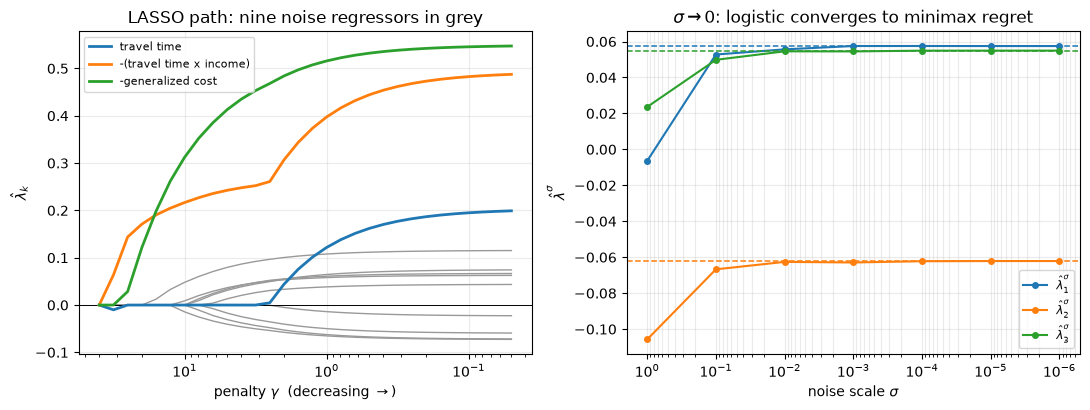

In [13]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))

# left: the LASSO regularization path
for k, nm in enumerate(names_aug):
    real = k < K
    ax[0].plot(gammas, path[:, k], lw=2.0 if real else 1.0,
               color=f'C{k}' if real else '0.6', zorder=3 if real else 1,
               label=nm if real else None)
ax[0].axhline(0, color='k', lw=.7)
ax[0].set_xscale('log'); ax[0].invert_xaxis()
ax[0].set_xlabel(r'penalty $\gamma$  (decreasing $\rightarrow$)')
ax[0].set_ylabel(r'$\hat\lambda_k$')
ax[0].set_title('LASSO path: nine noise regressors in grey')
ax[0].legend(fontsize=8, loc='upper left'); ax[0].grid(alpha=.25)

# right: the small-noise limit
for k in range(K_b):
    ax[1].semilogx(rows_sigma, rows_lam[:, k], 'o-', color=f'C{k}', ms=4,
                   label=rf'$\hat\lambda^\sigma_{k+1}$')
    ax[1].axhline(lam_lp[k], color=f'C{k}', ls='--', lw=1.1)
ax[1].set_xlabel(r'noise scale $\sigma$'); ax[1].set_ylabel(r'$\hat\lambda^\sigma$')
ax[1].set_title(r'$\sigma\to0$: logistic converges to minimax regret')
ax[1].invert_xaxis(); ax[1].legend(fontsize=8.5); ax[1].grid(alpha=.25, which='both')

plt.tight_layout(); plt.show()

*Left.* The regularization path, read left to right as the penalty is relaxed. The income interaction and generalized cost (coloured, thick) climb away from zero first and end largest. Travel time (also coloured) stays flat on zero through the middle of the range while several grey noise paths have already lifted off, and only rejoins them near the right-hand edge. The horizontal axis is a budget for moment-matching error; the picture shows which moments claim it first, which is a different question from which regressors are real.

*Right.* The coefficients of the scaled logistic regression against $\sigma$ on a log axis, with the linear-programming solution as dashed lines. The convergence of theorem 3.7 is visible and fast: by $\sigma=10^{-2}$ the estimates are within a few thousandths of the limit, and by $\sigma=10^{-4}$ they are on top of it.

## Summing up

* **Identification, existence and overfitting are three different failures**, and each has its own diagnostic. Identification is a statement about the null space of $D^2\ell$ — check its spectrum, not the optimizer's exit code. Existence is a linear program. Overfitting is what makes both worse.
* **The zero-cell problem is over-parametrization seen from the inside.** Theorem 3.6's detector returned $V>0$ for the book's three-regressor specification and fell monotonically as noise columns were added, exactly as the theory says it must, since each regressor is one more constraint on the same polytope. On the two-observation counterexample, $V=0$ and gradient ascent duly diverged.
* **The LASSO penalty is a tolerance on moment matching.** We verified the first-order conditions directly: no moment off by more than $\gamma$, every moment attached to a surviving coefficient off by exactly $\gamma$. Sparsity is the statement that some moments did not need a multiplier — and it is computed by soft thresholding, because plain gradient descent cannot minimize $|\lambda|$ at all. On this design the selection is instructive rather than reassuring: nine pure noise regressors entered the model before travel time did, because selection ranks moment gaps, not truth.
* **Minimax regret and logistic regression share a polytope and differ in one term.** The dual of the minimax regret LP has lecture 3's constraints and multipliers, with a linear objective in place of the entropy. The small-noise limit interpolates: $\sigma$ is the price of heterogeneity, and sending it to zero deletes the entropy.
* **The economics: how much dispersion in tastes are you willing to buy?** At $\sigma=1$ the estimator explains choices largely through unobserved heterogeneity; at $\sigma=0$ it insists that observed choices were exactly optimal and asks what preferences would make that true. Reproducing the book's table 3.1 to six figures — LP value $496.192$ from one algorithm, $\sigma\to0$ limit of a smooth problem from another — shows the two ends are one object.

## Exercises

**1. (Proof — the identification theorem.)** Complete the proof of theorem 3.5. Show that if $\ell(\lambda)=\ell(\lambda')$ for $\lambda\ne\lambda'$ then $(\lambda-\lambda')^\top D^2\ell(\lambda)(\lambda-\lambda')=0$, and that this quadratic form equals $\sum_i \mathbb{V}(\varphi_{iy}\mid i)$ for $\varphi = \Phi(\lambda-\lambda')$. Conclude, and then verify the converse. Finally, prove the sufficient condition: $\sum_y\phi_{iyk}=0$ for all $i,k$ implies identification.

**2. (Computation — how close to non-existence?)** For the travel-mode data, compute $V$ as regressors are added, but this time add *real* regressors (interactions of the existing ones, mode dummies, income splines) rather than noise. Find a specification for which $V$ falls below $10^{-3}$, and check what the optimizer does there: does it diverge, or merely become slow? Then relate the magnitude of $V$ to the condition number of $D^2\ell$ at the optimum.

**3. (Computation — ridge versus LASSO.)** Implement the ridge-penalized estimator (which, being smooth, needs no proximal step) and compare its path with the LASSO path of section 3 on the augmented design. Show numerically that ridge shrinks every coefficient but zeroes none, and state the corresponding first-order condition — what is the dual reading of $\gamma$ under an L2 penalty? Then implement the elastic net and locate the value of $\kappa$ at which the noise regressors stop being selected.

**4. (Computation — cross-validation.)** Choose $\gamma$ on the augmented travel-mode design by $k$-fold cross-validation of the out-of-sample log-likelihood, rather than by inspection of the path. Report the selected $\gamma$, the surviving regressors, and the out-of-sample likelihood against the unpenalized $K=12$ fit and the unpenalized $K=3$ fit. Which wins, and does the answer depend on the fold count?

**5. (Economics — what does $\sigma$ buy?)** In the small-noise experiment, compute for each $\sigma$ the fraction of observations whose realized choice is the model's argmax, and the entropy $\sum_{iy}\pi_{iy}\log\pi_{iy}$ of the fitted choice probabilities. Plot both against $\sigma$. (i) Explain the trade-off in terms of the dual: what is being purchased with entropy? (ii) An analyst reports that a logistic model "fits better" than a minimax regret model on the same data. In what sense can that statement be made precise, and in what sense is it empty? (iii) Lecture 11 studies choice under capacity constraints, where a second multiplier enters the same polytope. Conjecture what happens to the small-noise limit when a capacity constraint binds.

---

### Run notes

`FAST_MODE = True` uses a 30-point regularization path; `False` uses 40. Every assertion holds in both modes. The notebook uses numpy, scipy, pandas and matplotlib only: the two linear programs that listings `3-03` and `3-05` solve with Gurobi are solved here with HiGHS through `scipy.optimize.linprog`, so no licence is required.

Section 4 uses the legacy `np.random.RandomState(7)` rather than the notebook's `default_rng`, because reproducing the book's table 3.1 requires the exact random stream of listings `3-05` and `3-06`. That is the only place in the series where the legacy generator appears, and it is deliberate.

**Next:** lecture 5 leaves the closed forms behind. When the shocks are not Gumbel there is no formula for $\pi(U)$, and it has to be simulated — accept–reject, importance sampling, and the GHK simulator.